In [1]:
import json
from pymongo import MongoClient
from datetime import datetime

# ====== 1. Connect to MongoDB ======
client = MongoClient("mongodb://localhost:27017")   # or your MongoDB URL
db = client["market_sentiment"]                     # database name
collection = db["articles"]                         # collection name


# ====== 2. Load your JSON file ======
file_path = "/Users/jingyiwei/Library/Containers/com.tencent.xinWeChat/Data/Documents/xwechat_files/wxid_5829898281712_ec05/msg/file/2025-11/merged_all_50companies_20251123_175554.json"

with open(file_path, "r") as f:
    data = json.load(f)

print("Loaded", len(data), "records from JSON file.")

Loaded 1499983 records from JSON file.


In [2]:
# ====== 3. Inserted into MongoDB ======
result = collection.insert_many(data)

print("Inserted", len(result.inserted_ids), "documents into MongoDB.")

Inserted 1499983 documents into MongoDB.


In [3]:
doc = collection.find_one()
doc

{'_id': ObjectId('6923e0cefe20586ad7a52d50'),
 'article_id': '28b09631-963f-41ed-bde9-49b734a57e19',
 'title': 'AAPL jumps as Apple Inc. announces major product launch',
 'ticker': 'AAPL',
 'sector': 'Technology',
 'content': "Market participants closely monitored Apple Inc.'s performance in today's trading session. Strong fundamentals and positive market sentiment have supported AAPL's gains. Analysts continue to evaluate Apple Inc.'s position within the broader Technology industry. ",
 'full_text': "AAPL jumps as Apple Inc. announces major product launch. Market participants closely monitored Apple Inc.'s performance in today's trading session. Strong fundamentals and positive market sentiment have supported AAPL's gains. Analysts continue to evaluate Apple Inc.'s position within the broader Technology industry. ",
 'keywords': ['AAPL', 'Apple Inc.', 'Technology', 'stock market'],
 'sentiment_label': 'positive',
 'sentiment_score': 0.361,
 'published_at': datetime.datetime(2025, 2, 2

In [4]:
import pandas as pd
df = pd.DataFrame(data)
df.head()

,article_id,title,company_name,ticker,sector,content,full_text,keywords,sentiment_label,sentiment_score,...,month,day,day_of_week,stock_price,price_change_pct,price_52w_low,price_52w_high,source,word_count,_id
0,28b09631-963f-41ed-bde9-49b734a57e19,AAPL jumps as Apple Inc. announces major produ...,Apple Inc.,AAPL,Technology,Market participants closely monitored Apple In...,AAPL jumps as Apple Inc. announces major produ...,"AAPL, Apple Inc., Technology, stock market",positive,0.361,...,2,27,Thursday,275.00,2.92,260,275,MarketWatch,33,6923f620f292a07a2576958a
1,bc4b2ae8-9e7b-4247-a537-096cec6f95d9,Apple Inc. (AAPL) surges 2.9% on strong earnin...,Apple Inc.,AAPL,Technology,"Apple Inc. (AAPL), a leading company in the Te...",Apple Inc. (AAPL) surges 2.9% on strong earnin...,"AAPL, Apple Inc., Technology, stock market",positive,0.603,...,2,14,Friday,275.00,2.92,260,275,Bloomberg,37,6923f620f292a07a2576958b
2,de527c7d-fd21-43b2-82e2-1e395121cc5d,AAPL slides as Apple Inc. cuts full-year outlook,Apple Inc.,AAPL,Technology,The company's recent strategic initiatives hav...,AAPL slides as Apple Inc. cuts full-year outlo...,"AAPL, Apple Inc., Technology, stock market",negative,-0.445,...,10,15,Wednesday,267.62,0.16,260,275,Reuters,39,6923f620f292a07a2576958c
3,40b6cf8a-07c1-4650-ad43-78226d80f9c4,AAPL jumps as Apple Inc. announces major produ...,Apple Inc.,AAPL,Technology,Analysts continue to evaluate Apple Inc.'s pos...,AAPL jumps as Apple Inc. announces major produ...,"AAPL, Apple Inc., Technology, stock market",positive,0.528,...,8,5,Tuesday,275.00,2.92,260,275,CNBC,39,6923f620f292a07a2576958d
4,cab42b44-6e36-468f-9ccc-2d1b5bb07bc9,Apple Inc. (AAPL) drops 2.7% on disappointing ...,Apple Inc.,AAPL,Technology,The company's recent strategic initiatives hav...,Apple Inc. (AAPL) drops 2.7% on disappointing ...,"AAPL, Apple Inc., Technology, stock market",negative,-0.853,...,6,26,Thursday,260.00,-2.69,260,275,CNBC,38,6923f620f292a07a2576958e


Clean and normalize

In [5]:
from datetime import datetime
from pymongo import UpdateOne

BATCH_SIZE = 1000

def parse_published_at(value):
    """
    Convert strings like '2025/2/27 00:54' to datetime.
    Returns None if parsing fails.
    """
    if isinstance(value, datetime):
        return value
    if not isinstance(value, str):
        return None
    try:
        # adjust format if your strings differ
        return datetime.strptime(value, "%Y/%m/%d %H:%M")
    except Exception:
        return None

def normalize_keywords(value):
    """
    Turn 'AAPL, Apple Inc., Technology, stock market'
    into ['AAPL', 'Apple Inc.', 'Technology', 'stock market'].
    """
    if isinstance(value, list):
        return value
    if not isinstance(value, str):
        return None
    parts = [s.strip() for s in value.split(",")]
    parts = [s for s in parts if s]
    return parts or None

updated_count = 0
bulk_ops = []
cursor = collection.find({}, batch_size=BATCH_SIZE)

for doc in cursor:
    changes_set = {}
    changes_unset = {}

    # 1) published_at → datetime
    if "published_at" in doc:
        new_dt = parse_published_at(doc["published_at"])
        if new_dt is not None and new_dt != doc["published_at"]:
            changes_set["published_at"] = new_dt

    # 2) keywords → list of strings
    if "keywords" in doc:
        new_keywords = normalize_keywords(doc["keywords"])
        if new_keywords is not None and new_keywords != doc["keywords"]:
            changes_set["keywords"] = new_keywords

    # 3) company_name → company
    if "company_name" in doc and "company" not in doc:
        changes_set["company"] = doc["company_name"]
        changes_unset["company_name"] = ""

    if changes_set or changes_unset:
        update_doc = {}
        if changes_set:
            update_doc["$set"] = changes_set
        if changes_unset:
            update_doc["$unset"] = changes_unset

        bulk_ops.append(
            UpdateOne({"_id": doc["_id"]}, update_doc)
        )

    # execute in batches
    if len(bulk_ops) >= BATCH_SIZE:
        result = collection.bulk_write(bulk_ops, ordered=False)
        updated_count += result.modified_count
        print("Updated so far:", updated_count)
        bulk_ops = []

# flush remaining operations
if bulk_ops:
    result = collection.bulk_write(bulk_ops, ordered=False)
    updated_count += result.modified_count

print("Total documents modified:", updated_count)

Updated so far: 1000
Updated so far: 2000
Updated so far: 3000
Updated so far: 4000
Updated so far: 5000
Updated so far: 6000
Updated so far: 7000
Updated so far: 8000
Updated so far: 9000
Updated so far: 10000
Updated so far: 11000
Updated so far: 12000
Updated so far: 13000
Updated so far: 14000
Updated so far: 15000
Updated so far: 16000
Updated so far: 17000
Updated so far: 18000
Updated so far: 19000
Updated so far: 20000
Updated so far: 21000
Updated so far: 22000
Updated so far: 23000
Updated so far: 24000
Updated so far: 25000
Updated so far: 26000
Updated so far: 27000
Updated so far: 28000
Updated so far: 29000
Updated so far: 30000
Updated so far: 31000
Updated so far: 32000
Updated so far: 33000
Updated so far: 34000
Updated so far: 35000
Updated so far: 36000
Updated so far: 37000
Updated so far: 38000
Updated so far: 39000
Updated so far: 40000
Updated so far: 41000
Updated so far: 42000
Updated so far: 43000
Updated so far: 44000
Updated so far: 45000
Updated so far: 460

In [6]:
sample = collection.find(
    {},
    {
        "_id": 0,
        "article_id": 1,
        "company": 1,
        "company_name": 1,   # should now be gone / None
        "ticker": 1,
        "published_at": 1,
        "keywords": 1,
        "sentiment_label": 1,
        "sentiment_score": 1
    }
).limit(5)

for d in sample:
    print(d, "\n")

{'article_id': '28b09631-963f-41ed-bde9-49b734a57e19', 'ticker': 'AAPL', 'keywords': ['AAPL', 'Apple Inc.', 'Technology', 'stock market'], 'sentiment_label': 'positive', 'sentiment_score': 0.361, 'published_at': datetime.datetime(2025, 2, 27, 0, 54), 'company': 'Apple Inc.'} 

{'article_id': 'bc4b2ae8-9e7b-4247-a537-096cec6f95d9', 'ticker': 'AAPL', 'keywords': ['AAPL', 'Apple Inc.', 'Technology', 'stock market'], 'sentiment_label': 'positive', 'sentiment_score': 0.603, 'published_at': datetime.datetime(2025, 2, 14, 21, 29), 'company': 'Apple Inc.'} 

{'article_id': 'de527c7d-fd21-43b2-82e2-1e395121cc5d', 'ticker': 'AAPL', 'keywords': ['AAPL', 'Apple Inc.', 'Technology', 'stock market'], 'sentiment_label': 'negative', 'sentiment_score': -0.445, 'published_at': datetime.datetime(2025, 10, 15, 7, 14), 'company': 'Apple Inc.'} 

{'article_id': '40b6cf8a-07c1-4650-ad43-78226d80f9c4', 'ticker': 'AAPL', 'keywords': ['AAPL', 'Apple Inc.', 'Technology', 'stock market'], 'sentiment_label': 'posi

Build Daily Company Sentiment Collection

In [9]:
articles = db["articles"]
daily = db["daily_company_sentiment"]

# This MUST be unique, since ticker+date must identify a single row
daily.create_index(
    [("ticker", 1), ("date", 1)],
    unique=True
)

print("Index created.")

Index created.


In [11]:
pipeline = [
    {
        "$project": {
            "ticker": 1,
            "sentiment_score": 1,
            "sentiment_label": 1,
            "date": {
                "$dateTrunc": {
                    "date": "$published_at",
                    "unit": "day"
                }
            }
        }
    },
    {
        "$group": {
            "_id": {
                "ticker": "$ticker",
                "date": "$date"
            },
            "avg_score": {"$avg": "$sentiment_score"},
            "article_count": {"$sum": 1},
            "pos_count": {
                "$sum": {
                    "$cond": [{"$eq": ["$sentiment_label", "positive"]}, 1, 0]
                }
            },
            "neg_count": {
                "$sum": {
                    "$cond": [{"$eq": ["$sentiment_label", "negative"]}, 1, 0]
                }
            },
            "neu_count": {
                "$sum": {
                    "$cond": [{"$eq": ["$sentiment_label", "neutral"]}, 1, 0]
                }
            }
        }
    },
    {
        "$project": {
            "_id": 0,
            "ticker": "$_id.ticker",
            "date": "$_id.date",
            "avg_score": 1,
            "article_count": 1,
            "pos_count": 1,
            "neg_count": 1,
            "neu_count": 1
        }
    },
    {
        "$merge": {
            "into": "daily_company_sentiment",          # target collection
            "on": ["ticker", "date"],                  # unique key
            "whenMatched": "replace",
            "whenNotMatched": "insert"
        }
    }
]

result = list(articles.aggregate(pipeline))
print("Aggregation finished.")
print("Daily collection now:", daily.estimated_document_count())


Aggregation finished.
Daily collection now: 16350


以下只是看一下daily这个数据集 和简单的visual 可以不run

In [12]:
for doc in daily.find().sort("date", 1).limit(5):
    print(doc, "\n")

{'_id': ObjectId('6923e814ee065dbc8e773c55'), 'avg_score': -0.0913046875, 'article_count': 256, 'pos_count': 66, 'neg_count': 102, 'neu_count': 88, 'ticker': 'GE', 'date': datetime.datetime(2025, 1, 1, 0, 0)} 

{'_id': ObjectId('6923e814ee065dbc8e773ba6'), 'avg_score': -0.028511904761904763, 'article_count': 168, 'pos_count': 46, 'neg_count': 52, 'neu_count': 70, 'ticker': 'TGT', 'date': datetime.datetime(2025, 1, 1, 0, 0)} 

{'_id': ObjectId('6923e814ee065dbc8e7741b6'), 'avg_score': 0.003941176470588241, 'article_count': 68, 'pos_count': 18, 'neg_count': 20, 'neu_count': 30, 'ticker': 'TSLA', 'date': datetime.datetime(2025, 1, 1, 0, 0)} 

{'_id': ObjectId('6923e814ee065dbc8e773d0f'), 'avg_score': -0.12052272727272727, 'article_count': 88, 'pos_count': 12, 'neg_count': 34, 'neu_count': 42, 'ticker': 'NFLX', 'date': datetime.datetime(2025, 1, 1, 0, 0)} 

{'_id': ObjectId('6923e814ee065dbc8e773a9c'), 'avg_score': -0.011969230769230768, 'article_count': 260, 'pos_count': 76, 'neg_count': 

In [16]:
docs_daily = list(daily.find().sort("date", 1).limit(30))
df_daily = pd.DataFrame(docs_daily)

df_daily.head()

,_id,avg_score,article_count,pos_count,neg_count,neu_count,ticker,date
0,6923e814ee065dbc8e7742fe,0.024150,240,80,66,94,ABBV,2025-01-01
1,6923e814ee065dbc8e7741b6,0.003941,68,18,20,30,TSLA,2025-01-01
2,6923e814ee065dbc8e774865,0.054855,234,90,68,76,CAT,2025-01-01
3,6923e814ee065dbc8e7754ad,-0.045787,216,62,72,82,HON,2025-01-01
4,6923e814ee065dbc8e773d0f,-0.120523,88,12,34,42,NFLX,2025-01-01


In [21]:
# aggregate per ticker
ticker_summary = df_daily.groupby("ticker").agg(
    avg_sentiment=("avg_score", "mean"),
    total_articles=("article_count", "sum")
).reset_index()

ticker_summary

,ticker,avg_sentiment,total_articles
0,AAPL,0.074294,68
1,ABBV,0.024150,240
2,AMZN,0.031097,62
3,BA,-0.011969,260
4,BRK.B,-0.020147,258
5,CAT,0.054855,234
6,CSCO,0.063892,222
7,GE,-0.091305,256
8,GOOGL,0.090958,48
9,GS,0.102480,50


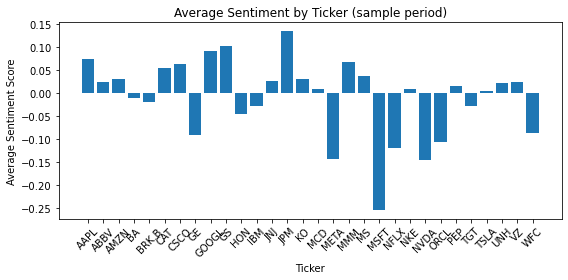

In [22]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.bar(ticker_summary["ticker"], ticker_summary["avg_sentiment"])
plt.xlabel("Ticker")
plt.ylabel("Average Sentiment Score")
plt.title("Average Sentiment by Ticker (sample period)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
from datetime import datetime, timedelta

ticker = "AAPL"  # change to any ticker you want
days = 30

end_date = datetime.utcnow()
start_date = end_date - timedelta(days=days)

cursor = daily.find(
    {
        "ticker": ticker,
        "date": {"$gte": start_date}
    },
    {
        "_id": 0,
        "ticker": 1,
        "date": 1,
        "avg_score": 1,
        "article_count": 1,
        "pos_count": 1,
        "neg_count": 1,
        "neu_count": 1
    }
).sort("date", 1)

trend = list(cursor)
for row in trend[:5]:
    print(row)

{'avg_score': -0.44728, 'article_count': 50, 'pos_count': 4, 'neg_count': 42, 'neu_count': 4, 'ticker': 'AAPL', 'date': datetime.datetime(2025, 10, 26, 0, 0)}
{'avg_score': -0.3532272727272727, 'article_count': 44, 'pos_count': 6, 'neg_count': 34, 'neu_count': 4, 'ticker': 'AAPL', 'date': datetime.datetime(2025, 10, 27, 0, 0)}
{'avg_score': -0.5036578947368421, 'article_count': 76, 'pos_count': 2, 'neg_count': 64, 'neu_count': 10, 'ticker': 'AAPL', 'date': datetime.datetime(2025, 10, 28, 0, 0)}
{'avg_score': -0.49451515151515146, 'article_count': 66, 'pos_count': 2, 'neg_count': 56, 'neu_count': 8, 'ticker': 'AAPL', 'date': datetime.datetime(2025, 10, 29, 0, 0)}
{'avg_score': -0.4779310344827586, 'article_count': 58, 'pos_count': 0, 'neg_count': 50, 'neu_count': 8, 'ticker': 'AAPL', 'date': datetime.datetime(2025, 10, 30, 0, 0)}


In [24]:
df_trend = pd.DataFrame(trend)
df_trend.head()

,avg_score,article_count,pos_count,neg_count,neu_count,ticker,date
0,-0.447280,50,4,42,4,AAPL,2025-10-26
1,-0.353227,44,6,34,4,AAPL,2025-10-27
2,-0.503658,76,2,64,10,AAPL,2025-10-28
3,-0.494515,66,2,56,8,AAPL,2025-10-29
4,-0.477931,58,0,50,8,AAPL,2025-10-30


In [25]:
summary_row = pd.DataFrame({
    "start_date": [df_trend["date"].min().date()],
    "end_date":   [df_trend["date"].max().date()],
    "days":       [df_trend["date"].nunique()],
    "avg_sentiment": [df_trend["avg_score"].mean()],
    "min_sentiment": [df_trend["avg_score"].min()],
    "max_sentiment": [df_trend["avg_score"].max()],
    "total_articles": [df_trend["article_count"].sum()],
    "pos_articles": [df_trend["pos_count"].sum()],
    "neg_articles": [df_trend["neg_count"].sum()],
    "neu_articles": [df_trend["neu_count"].sum()],
})

summary_row

,start_date,end_date,days,avg_sentiment,min_sentiment,max_sentiment,total_articles,pos_articles,neg_articles,neu_articles
0,2025-10-26,2025-11-23,29,-0.569353,-0.673231,-0.353227,1830,16,1774,40


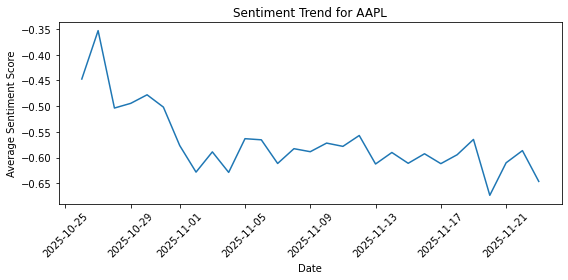

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(df_trend["date"], df_trend["avg_score"])
plt.xlabel("Date")
plt.ylabel("Average Sentiment Score")
plt.title(f"Sentiment Trend for {df_trend['ticker'].iloc[0]}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()